# HyperRAG V2 - Notebook 7: Chunk & Ranker Debug

**Goal:** Understand why Simple RAG and HyperRAG produce identical EM/F1, and fix it with chunking.

## What this notebook does

1. **Question subset** -- questions where Simple RAG EM=0 but HyperRAG EM=1 (graph expansion wins)
2. **Mini test corpus** -- only pages needed for those questions
3. **Chunk inspector** -- which chunks retrieved from which page, with similarity scores
4. **Chunk size experiment** -- 256 to 2048 chars, compare EM for Simple RAG vs HyperRAG
5. **k experiment** -- how many chunks to retrieve
6. **LLM experiment** -- optional, compare models on chunk-based context

## Why chunking matters

Current approach embeds the entire page (~10K chars) as one vector.
With smaller chunks, each embedding is more focused = better semantic match.

```
Full-page: query -> embed(entire_page) -> cosine sim -> top-k pages
Chunked  : query -> embed(paragraph)   -> cosine sim -> top-k chunks  <- more precise
```


In [1]:
# ================================================================
# USER PARAMETERS -- change these to run different experiments
# ================================================================

N_QUESTIONS   = 100          # max interesting questions (Simple EM=0, Hyper EM=1)
CHUNK_SIZES   = [256, 512, 1024, 2048]  # chars to experiment with
CHUNK_OVERLAP = 64           # overlap between consecutive chunks
K             = 5            # pages/chunks to retrieve
EXPAND_K      = 3            # HyperRAG: extra neighbor chunks
INSPECT_Q_IDX = 0            # which question to inspect in detail (0-based)

# LLM experiment (slow -- set True only when needed)
RUN_LLM     = False
LLM_MODELS  = [
    ('flan-t5-small', 'google/flan-t5-small', False),  # (label, hf_id, is_causal_lm)
    ('flan-t5-base',  'google/flan-t5-base',  False),
    # ('llama-3.2-3B', 'meta-llama/Llama-3.2-3B-Instruct', True),  # needs HF token
]
MAX_CTX_CHARS = 2000  # context chars sent to LLM

print(f'N={N_QUESTIONS} CHUNK_SIZES={CHUNK_SIZES} K={K} EXPAND_K={EXPAND_K} RUN_LLM={RUN_LLM}')


N=100 CHUNK_SIZES=[256, 512, 1024, 2048] K=5 EXPAND_K=3 RUN_LLM=False


In [2]:
import json, sys
from pathlib import Path
from collections import Counter, defaultdict

import faiss, numpy as np, networkx as nx
import matplotlib.pyplot as plt, matplotlib.patches as mpatches

if Path('utils.py').exists():       BASE_DIR = Path('.')
elif Path('v2/utils.py').exists():  BASE_DIR = Path('v2')
else: raise FileNotFoundError('Run from v2/ or HyperRAG-M2/')

DATA_DIR = BASE_DIR / 'data'
sys.path.insert(0, str(BASE_DIR))
from utils import embed_texts, build_index, retrieve, compute_em, compute_f1

with open(DATA_DIR / 'corpus_001.json')    as f: corpus    = json.load(f)
with open(DATA_DIR / 'questions_001.json') as f: questions = json.load(f)
print(f'Corpus: {len(corpus)} pages  Questions: {len(questions)}')

for fname in ['results_simple_rag.json', 'results_hyperrag.json']:
    if not (DATA_DIR / fname).exists():
        raise FileNotFoundError(f'{fname} not found. Run notebooks 02 and 04 first.')

with open(DATA_DIR / 'results_simple_rag.json') as f: simple_results = json.load(f)
with open(DATA_DIR / 'results_hyperrag.json')   as f: hyper_results  = json.load(f)
simple_per_q = {r['id']: r for r in simple_results['per_question']}
hyper_per_q  = {r['id']: r for r in hyper_results['per_question']}
print(f'Simple EM={simple_results["mean_em"]:.3f}  HyperRAG EM={hyper_results["mean_em"]:.3f}')


W0429 17:02:11.241000 315588 site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


Corpus: 9999 pages  Questions: 5329
Simple EM=0.682  HyperRAG EM=0.756


---
## Section 1 -- Build Question Subset (Simple EM=0, HyperRAG EM=1)

We select questions where Simple RAG retrieval failed but HyperRAG succeeded via graph expansion.
These are the cases that prove the graph adds real value -- and the best cases to debug.


In [3]:
interesting = []
for q in questions:
    sq = simple_per_q.get(q['id'])
    hq = hyper_per_q.get(q['id'])
    if sq and hq and sq['em'] == 0.0 and hq['em'] == 1.0:
        interesting.append({'question': q, 'simple_em': 0.0, 'hyper_em': 1.0,
                            'simple_titles': sq['retrieved_titles'],
                            'hyper_sr': hq['supporting_recall']})

subset           = interesting[:N_QUESTIONS]
subset_questions = [item['question'] for item in subset]

print(f'Total questions : {len(questions)}')
print(f'Interesting     : {len(interesting)} ({100*len(interesting)/len(questions):.1f}%)')
print(f'Subset taken    : {len(subset)}')
print()

# EM pattern breakdown
patterns = Counter()
for q in questions:
    sq, hq = simple_per_q.get(q['id']), hyper_per_q.get(q['id'])
    if sq and hq:
        patterns[f'simple={int(sq["em"])} hyper={int(hq["em"])}'] += 1
print('EM pattern breakdown across all questions:')
for pat, cnt in sorted(patterns.items()):
    note = '  <-- our subset' if '0 hyper=1' in pat else ''
    print(f'  {pat:30s}: {cnt:5d} ({100*cnt/len(questions):.1f}%){note}')


Total questions : 5329
Interesting     : 395 (7.4%)
Subset taken    : 100

EM pattern breakdown across all questions:
  simple=0 hyper=0              :  1301 (24.4%)
  simple=0 hyper=1              :   395 (7.4%)  <-- our subset
  simple=1 hyper=1              :  3633 (68.2%)


In [4]:
print(f'{"#":<4} {"Gold":<28} {"Supporting Pages":<40} Question')
print('-' * 110)
for i, item in enumerate(subset[:20]):
    q  = item['question']
    sp = ' | '.join(q['supporting_titles'][:2])
    print(f'{i:<4} {q["answer"]:<28} {sp[:38]:<40} {q["question"][:50]}')


#    Gold                         Supporting Pages                         Question
--------------------------------------------------------------------------------------------------------------
0    Jaime Meline                 Fast Cars, Danger, Fire and Knives | E   Fast Cars, Danger, Fire and Knives includes guest 
1    Victor John Mature           Victor Mature | Samson and Delilah (19   What American stage, film, and television actor  w
2    1988                         2016 Marrakesh ePrix | Sébastien Buemi   What year was the winner of the 2016 Marrakesh ePr
3    the Sumerians                Cuneiform script | Autograph (Assyriol   Who invented the type of script used in autographs
4    February 5, 1953             2014–15 Michigan Wolverines men's bask   What is the birth date of the coach of the 2014-15
5    Academy of Motion Picture Arts and Sciences Academy Award for Best Director | Chri   Which organization presents the award in which Chr
6    Exeter Book                  

---
## Section 2 -- Build Mini Test Corpus

Only pages needed by the subset: supporting (gold) pages + pages Simple RAG retrieved.
Saved as `data/test_questions_subset.json` and `data/test_corpus_subset.json`.


In [5]:
needed_titles = set()
for item in subset:
    needed_titles.update(item['question']['supporting_titles'])
    needed_titles.update(item['simple_titles'])

title_to_page = {p['title']: p for p in corpus}
test_corpus   = [title_to_page[t] for t in needed_titles if t in title_to_page]
print(f'Needed: {len(needed_titles)} titles  Found: {len(test_corpus)}  Missing: {len(needed_titles)-len(test_corpus)}')

with open(DATA_DIR / 'test_questions_subset.json', 'w') as f: json.dump(subset_questions, f, indent=2)
with open(DATA_DIR / 'test_corpus_subset.json',    'w') as f: json.dump(test_corpus, f, indent=2)
print(f'Saved test_questions_subset.json ({len(subset_questions)} q)')
print(f'Saved test_corpus_subset.json    ({len(test_corpus)} pages)')

lengths = [len(p['text']) for p in test_corpus]
print(f'Page lengths: min={min(lengths):,} max={max(lengths):,} mean={int(np.mean(lengths)):,}')


Needed: 588 titles  Found: 585  Missing: 3
Saved test_questions_subset.json (100 q)
Saved test_corpus_subset.json    (585 pages)
Page lengths: min=341 max=192,282 mean=18,010


---
## Section 3 -- Chunking & Retrieval Functions

```
Page text (10,000 chars)
  chunk 0: chars [0   :512]  <- embedded as one vector
  chunk 1: chars [448 :960]  <- 64-char overlap
  ...
```


In [6]:
def split_into_chunks(text: str, chunk_size: int = 512, overlap: int = 64) -> list:
    """Split text into overlapping chunks at word boundaries."""
    if len(text) <= chunk_size: return [text.strip()]
    chunks, start = [], 0
    while start < len(text):
        end = min(start + chunk_size, len(text))
        if end < len(text):
            ls = text.rfind(' ', start, end)
            if ls > start: end = ls
        chunk = text[start:end].strip()
        if chunk: chunks.append(chunk)
        nxt = end - overlap
        start = nxt if nxt > start else end
    return chunks


def build_chunk_corpus(corpus, chunk_size, overlap=64):
    """Convert page corpus to chunk corpus. Each chunk has title, chunk_idx, n_chunks, text."""
    docs = []
    for pi, page in enumerate(corpus):
        cks = split_into_chunks(page['text'], chunk_size, overlap)
        for i, c in enumerate(cks):
            docs.append({'title': page['title'], 'chunk_idx': i, 'n_chunks': len(cks), 'text': c, '_page_idx': pi})
    return docs


def build_chunk_index(corpus, chunk_size, overlap=64):
    """Build FAISS index on chunks. Returns (faiss_index, chunk_docs)."""
    docs = build_chunk_corpus(corpus, chunk_size, overlap)
    vecs = embed_texts([d['text'] for d in docs])
    idx  = faiss.IndexFlatIP(vecs.shape[1]); idx.add(vecs)
    return idx, docs


def retrieve_chunks(query, index, chunk_docs, k=5):
    """Top-k chunk retrieval from chunk index."""
    qv = embed_texts([query])
    scores, indices = index.search(qv, k)
    results = []
    for ix, sc in zip(indices[0], scores[0]):
        if 0 <= ix < len(chunk_docs):
            c = dict(chunk_docs[ix]); c['_score'] = float(sc); results.append(c)
    return results


def simple_rag_chunked(question, chunk_index, chunk_docs, k=5):
    """Simple RAG on chunks. Returns (context, page_titles, chunks)."""
    cks = retrieve_chunks(question, chunk_index, chunk_docs, k=k)
    return '\n\n'.join(c['text'] for c in cks), list(dict.fromkeys(c['title'] for c in cks)), cks


def hyper_rag_chunked(question, chunk_index, chunk_docs, corpus, graph, k=5, expand_k=3):
    """
    HyperRAG on chunks:
    1. Retrieve top-k chunks  2. Find 1-hop graph neighbors of source pages
    3. Re-rank neighbor chunks by similarity  4. Add top expand_k
    Returns (context, page_titles, all_chunks).
    """
    t2p    = {p['title']: p for p in corpus}
    init   = retrieve_chunks(question, chunk_index, chunk_docs, k=k)
    i_ttls = set(c['title'] for c in init)

    nbr_ttls = set()
    for t in i_ttls:
        if graph.has_node(t):
            for nbr in list(graph.successors(t)) + list(graph.predecessors(t)):
                if nbr in t2p and nbr not in i_ttls: nbr_ttls.add(nbr)

    nbr_cks = [c for c in chunk_docs if c['title'] in nbr_ttls]
    expanded = []
    if nbr_cks and expand_k > 0:
        nv  = embed_texts([c['text'] for c in nbr_cks])
        qv  = embed_texts([question])
        sc  = (qv @ nv.T)[0]
        top = sc.argsort()[::-1][:expand_k]
        expanded = [dict(nbr_cks[i]) for i in top]
        for i2, ix in enumerate(top): expanded[i2]['_score'] = float(sc[ix])

    all_c = init + expanded
    return '\n\n'.join(c['text'] for c in all_c), list(dict.fromkeys(c['title'] for c in all_c)), all_c


print('All chunking/RAG functions defined.')
demo = split_into_chunks(test_corpus[0]['text'], 512, 64)
print(f'Demo: "{test_corpus[0]["title"]}" {len(test_corpus[0]["text"]):,} chars -> {len(demo)} chunks@512')


All chunking/RAG functions defined.
Demo: "USS LST-510" 8,394 chars -> 20 chunks@512


---
## Section 4 -- Build Indexes and Graph


In [7]:
print('Building full-page FAISS index on test corpus...')
full_index         = build_index(test_corpus)
title_to_page_test = {p['title']: p for p in test_corpus}
print(f'Index: {full_index.ntotal} vectors')

print('Building hyperlink graph (on full corpus for edge density)...')
all_titles = {p['title'] for p in corpus}
graph = nx.DiGraph(); graph.add_nodes_from(all_titles)
for page in corpus:
    for link in page['links']:
        if link in all_titles and link != page['title']: graph.add_edge(page['title'], link)
print(f'Graph: {graph.number_of_nodes()} nodes, {graph.number_of_edges()} edges')


Building full-page FAISS index on test corpus...
Loading model: sentence-transformers/all-MiniLM-L6-v2 ...
Model loaded.


Batches:   0%|          | 0/19 [00:00<?, ?it/s]

Index: 585 vectors
Building hyperlink graph (on full corpus for edge density)...
Graph: 9999 nodes, 86244 edges


---
## Section 5 -- Chunk Inspector: One Question in Detail

For one question shows:
1. Which pages FAISS retrieves (title, score, gold?)
2. How those pages split into chunks
3. Cosine similarity of each chunk to the query
4. Which chunk contains the gold answer

Change `INSPECT_Q_IDX` in config to inspect a different question.


In [8]:
CS   = 512  # chunk size for inspection
item = subset[INSPECT_Q_IDX]
q    = item['question']
gold_set = set(q['supporting_titles'])

print('='*80)
print(f'Q[{INSPECT_Q_IDX}]: {q["question"]}')
print(f'Gold answer : {q["answer"]}')
print(f'Supporting  : {q["supporting_titles"]}')
print(f'Simple EM=0 (failed)  HyperRAG EM=1 (graph succeeded)')
print('='*80)

# Step 1: full-page retrieval (what Simple RAG does)
ret_pages = retrieve(q['question'], full_index, test_corpus, k=K)
print(f'\nSTEP 1 -- Full-page retrieval (Simple RAG, k={K})')
print(f'{"Rank":<5} {"Score":>6}  {"Gold":<4} Title')
print('-'*65)
for i, p in enumerate(ret_pages, 1):
    g = 'G' if p['title'] in gold_set else ' '
    a = '[HAS ANSWER]' if q['answer'].lower() in p['text'].lower() else ''
    print(f'{i:<5} {p["_score"]:>6.3f}  {g:<4} {p["title"][:50]} {a}')

# Step 2: embed chunks, score each chunk vs query
print(f'\nSTEP 2 -- Chunk scoring (chunk_size={CS}), ranked by similarity')
qv   = embed_texts([q['question']])
rows = []
for ri, p in enumerate(ret_pages, 1):
    cks = split_into_chunks(p['text'], CS, CHUNK_OVERLAP)
    cvs = embed_texts(cks)
    scs = (qv @ cvs.T)[0]
    for ci, (ck, sc) in enumerate(zip(cks, scs)):
        rows.append({'page_rank': ri, 'title': p['title'],
                     'chunk_idx': ci, 'n_chunks': len(cks),
                     'score': float(sc), 'has_answer': q['answer'].lower() in ck.lower(), 'text': ck})

rows.sort(key=lambda x: -x['score'])
print(f'{"Rank":<5} {"Score":>6}  {"Ans":<6} {"Page":<30}  Chunk   Preview')
print('-'*95)
for i, r in enumerate(rows[:15], 1):
    a    = 'ANSWER' if r['has_answer'] else '      '
    prev = r['text'][:55].replace('\n', ' ')
    print(f'{i:<5} {r["score"]:>6.3f}  {a}  {r["title"][:28]:<30}  [{r["chunk_idx"]}/{r["n_chunks"]-1}]  "{prev}"')

ans_rows = [r for r in rows if r['has_answer']]
print(f'\nChunks with gold answer: {len(ans_rows)} of {len(rows)}')
if ans_rows:
    best_r = rows.index(ans_rows[0]) + 1
    print(f'Best answer-chunk rank: #{best_r}  ({"RETRIEVED" if best_r <= K else "MISSED"} by Simple RAG k={K})')


Q[0]: Fast Cars, Danger, Fire and Knives includes guest appearances from which hip hop record executive?
Gold answer : Jaime Meline
Supporting  : ['Fast Cars, Danger, Fire and Knives', 'El-P']
Simple EM=0 (failed)  HyperRAG EM=1 (graph succeeded)

STEP 1 -- Full-page retrieval (Simple RAG, k=5)
Rank   Score  Gold Title
-----------------------------------------------------------------
1      0.479       Dr. Dre 
2      0.466       2 Live Crew 
3      0.463  G    Fast Cars, Danger, Fire and Knives 
4      0.459       Venetian Snares 
5      0.458       Fire Squad 

STEP 2 -- Chunk scoring (chunk_size=512), ranked by similarity


Batches:   0%|          | 0/8 [00:00<?, ?it/s]

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Rank   Score  Ans    Page                            Chunk   Preview
-----------------------------------------------------------------------------------------------
1      0.594          Fast Cars, Danger, Fire and     [0/7]  "2005 EP by Aesop Rock Fast Cars, Danger, Fire and Knive"
2      0.565          Fast Cars, Danger, Fire and     [6/7]  "Aesop Rock Chart History (Top R&B/Hip-Hop Albums) ". Bi"
3      0.505          Dr. Dre                         [15/249]  "ro-hop scene that dominated early-mid 1980s West Coast "
4      0.497          Fast Cars, Danger, Fire and     [3/7]  "("the world's tiniest woman"). The subsequent pressing "
5      0.494          Fast Cars, Danger, Fire and     [5/7]  "Michaelangelo (March 2005). "Busdriver: Fear of a Black"
6      0.494          Fast Cars, Danger, Fire and     [7/7]  "Fast Cars, Danger, Fire and Knives at Discogs (list of "
7      0.492          Dr. Dre                         [212/249]  "re's success" . The Washington Post . ISSN 0190-8286

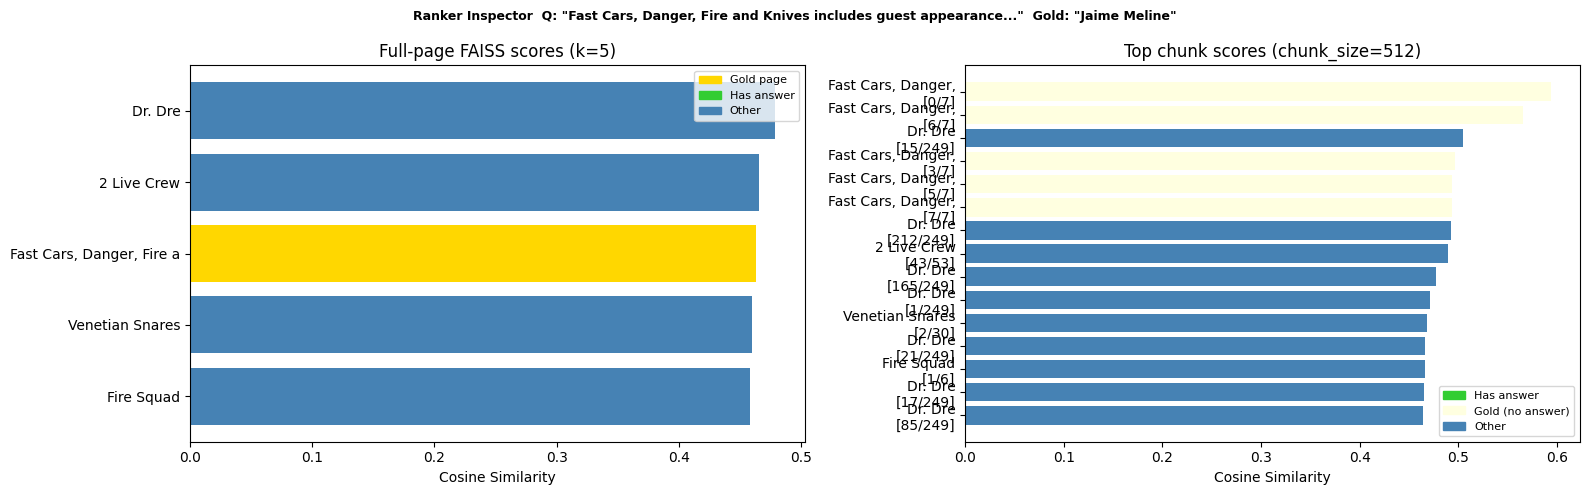

Saved: data/chunk_rank_inspector.png


In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle(f'Ranker Inspector  Q: "{q["question"][:60]}..."  Gold: "{q["answer"]}"',
             fontsize=9, fontweight='bold')

# Full-page scores
pt = [p['title'][:25] for p in ret_pages]
ps = [p['_score']     for p in ret_pages]
pc = ['gold' if p['title'] in gold_set else
      ('limegreen' if q['answer'].lower() in p['text'].lower() else 'steelblue')
      for p in ret_pages]
ax1.barh(pt[::-1], ps[::-1], color=pc[::-1])
ax1.set_title(f'Full-page FAISS scores (k={K})')
ax1.set_xlabel('Cosine Similarity')
ax1.legend(handles=[mpatches.Patch(color='gold',label='Gold page'),
                    mpatches.Patch(color='limegreen',label='Has answer'),
                    mpatches.Patch(color='steelblue',label='Other')], fontsize=8)

# Chunk scores (top 15)
top = rows[:15]
cl  = [f'{r["title"][:18]}\n[{r["chunk_idx"]}/{r["n_chunks"]-1}]' for r in top]
cs2 = [r['score']     for r in top]
cc2 = ['limegreen'  if r['has_answer'] else
       ('lightyellow' if r['title'] in gold_set else 'steelblue') for r in top]
ax2.barh(cl[::-1], cs2[::-1], color=cc2[::-1])
ax2.set_title(f'Top chunk scores (chunk_size={CS})')
ax2.set_xlabel('Cosine Similarity')
ax2.legend(handles=[mpatches.Patch(color='limegreen',label='Has answer'),
                    mpatches.Patch(color='lightyellow',label='Gold (no answer)'),
                    mpatches.Patch(color='steelblue',label='Other')], fontsize=8)

plt.tight_layout()
plt.savefig(str(DATA_DIR / 'chunk_rank_inspector.png'), dpi=120, bbox_inches='tight')
plt.show()
print('Saved: data/chunk_rank_inspector.png')


In [10]:
# Show how HyperRAG expands via graph neighbors
init_ttls = [p['title'] for p in ret_pages]
nbr_ttls  = set()
for t in init_ttls:
    if graph.has_node(t):
        for nbr in list(graph.successors(t)) + list(graph.predecessors(t)):
            if nbr in title_to_page and nbr not in set(init_ttls): nbr_ttls.add(nbr)

print(f'Initial FAISS pages ({len(init_ttls)}): {init_ttls}')
print(f'Graph neighbors found in corpus: {len(nbr_ttls)}')
print()

if nbr_ttls:
    nbr_pages = [title_to_page[t] for t in nbr_ttls if t in title_to_page]
    nv  = embed_texts([p['text'] for p in nbr_pages])
    qv2 = embed_texts([q['question']])
    sc2 = (qv2 @ nv.T)[0]
    ranked = sorted(zip(nbr_pages, sc2), key=lambda x: -x[1])
    print(f'{"Rank":<5} {"Score":>6}  {"Gold":<4} {"Ans":<8} Title')
    print('-'*65)
    for ri, (p, s) in enumerate(ranked[:10], 1):
        g   = 'G' if p['title'] in gold_set else ' '
        a   = 'ANSWER' if q['answer'].lower() in p['text'].lower() else '      '
        sel = '  <- selected' if ri <= EXPAND_K else ''
        print(f'{ri:<5} {s:>6.3f}  {g:<4} {a}  {p["title"][:45]}{sel}')

    top_exp  = [p for p, _ in ranked[:EXPAND_K]]
    simple_c = '\n\n'.join(p['text'] for p in ret_pages)
    hyper_c  = '\n\n'.join(p['text'] for p in ret_pages + top_exp)
    print(f'\nRetrieval EM check:')
    print(f'  Simple RAG : {compute_em(simple_c, q["answer"])}')
    print(f'  HyperRAG   : {compute_em(hyper_c,  q["answer"])}')
else:
    print('No graph neighbors in test corpus subset.')
    print('(They exist in the full 9999-page corpus -- test corpus is a subset.)')


Initial FAISS pages (5): ['Dr. Dre', '2 Live Crew', 'Fast Cars, Danger, Fire and Knives', 'Venetian Snares', 'Fire Squad']
Graph neighbors found in corpus: 65



Batches:   0%|          | 0/3 [00:00<?, ?it/s]

Rank   Score  Gold Ans      Title
-----------------------------------------------------------------
1      0.443  G    ANSWER  El-P  <- selected
2      0.439               DJ Muggs  <- selected
3      0.436               Up in Smoke Tour  <- selected
4      0.426               Bad Meets Evil
5      0.405               Hell: The Sequel
6      0.404               Xzibit
7      0.397               Bad Boy Records
8      0.390               Proof (rapper)
9      0.388               Nelly
10     0.386               Eminem

Retrieval EM check:
  Simple RAG : 0.0
  HyperRAG   : 1.0


---
## Section 6 -- Chunk Size Experiment

Loop over CHUNK_SIZES, build chunk index, evaluate Simple RAG + HyperRAG, compare retrieval EM.

Also includes full-page baseline for comparison.

> **Note:** This measures **retrieval EM** (gold answer in context?), not LLM generation EM.


In [11]:
try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(x, **kw): return x

exp_results = []

# Baseline: full-page (1 chunk per page)
print('=== Baseline: full-page ===')
fp_docs  = [{'title': p['title'], 'chunk_idx': 0, 'n_chunks': 1, 'text': p['text'], '_page_idx': i}
            for i, p in enumerate(test_corpus)]
fp_vecs  = embed_texts([d['text'] for d in fp_docs])
fp_index = faiss.IndexFlatIP(fp_vecs.shape[1]); fp_index.add(fp_vecs)

for sname, fn in [
    ('Simple-fullpage', lambda q,ix,ds: simple_rag_chunked(q, ix, ds, k=K)),
    ('Hyper-fullpage',  lambda q,ix,ds: hyper_rag_chunked(q, ix, ds, corpus, graph, k=K, expand_k=EXPAND_K)),
]:
    ems, f1s = [], []
    for q in tqdm(subset_questions, desc=sname, leave=False):
        ctx, _, _ = fn(q['question'], fp_index, fp_docs)
        ems.append(compute_em(ctx, q['answer']))
        f1s.append(compute_f1(ctx, q['answer']))
    exp_results.append({'chunk_size': 'full_page', 'system': sname,
                        'mean_em': float(np.mean(ems)), 'mean_f1': float(np.mean(f1s)), 'per_q_em': ems})
    print(f'  {sname}: EM={np.mean(ems):.3f}')

# Chunked
for cs in CHUNK_SIZES:
    print(f'=== chunk_size={cs} ===')
    c_idx, c_docs = build_chunk_index(test_corpus, cs, CHUNK_OVERLAP)
    print(f'  {len(c_docs)} chunks from {len(test_corpus)} pages')
    for sname, fn in [
        ('Simple-RAG', lambda q,ix,ds: simple_rag_chunked(q, ix, ds, k=K)),
        ('HyperRAG',   lambda q,ix,ds: hyper_rag_chunked(q, ix, ds, corpus, graph, k=K, expand_k=EXPAND_K)),
    ]:
        ems, f1s = [], []
        for q in tqdm(subset_questions, desc=f'{sname} cs={cs}', leave=False):
            ctx, _, _ = fn(q['question'], c_idx, c_docs)
            ems.append(compute_em(ctx, q['answer']))
            f1s.append(compute_f1(ctx, q['answer']))
        exp_results.append({'chunk_size': cs, 'system': sname,
                            'mean_em': float(np.mean(ems)), 'mean_f1': float(np.mean(f1s)), 'per_q_em': ems})
        print(f'  {sname}: EM={np.mean(ems):.3f}')

print('\nDone. Results table below.')


=== Baseline: full-page ===


Batches:   0%|          | 0/19 [00:00<?, ?it/s]

Simple-fullpage:   0%|          | 0/100 [00:00<?, ?it/s]

  Simple-fullpage: EM=0.000


Hyper-fullpage:   0%|          | 0/100 [00:00<?, ?it/s]

...

Batches:   0%|          | 0/12 [00:00<?, ?it/s]

Batches:   0%|          | 0/4 [00:00<?, ?it/s]

Batches:   0%|          | 0/8 [00:00<?, ?it/s]

Batches:   0%|          | 0/3 [00:00<?, ?it/s]

  HyperRAG: EM=0.490

Done. Results table below.


In [12]:
print(f'{"Chunk Size":<15} {"System":<22} {"Mean EM":>8} {"Mean F1":>8}')
print('-'*57)
for r in exp_results:
    print(f'{str(r["chunk_size"]):<15} {r["system"]:<22} {r["mean_em"]:>8.3f} {r["mean_f1"]:>8.5f}')


Chunk Size      System                  Mean EM  Mean F1
---------------------------------------------------------
full_page       Simple-fullpage           0.000  0.00025
full_page       Hyper-fullpage            0.910  0.00020
256             Simple-RAG                0.090  0.00531
256             HyperRAG                  0.250  0.00539
512             Simple-RAG                0.100  0.00340
512             HyperRAG                  0.320  0.00336
1024            Simple-RAG                0.090  0.00181
1024            HyperRAG                  0.380  0.00194
2048            Simple-RAG                0.090  0.00110
2048            HyperRAG                  0.490  0.00130


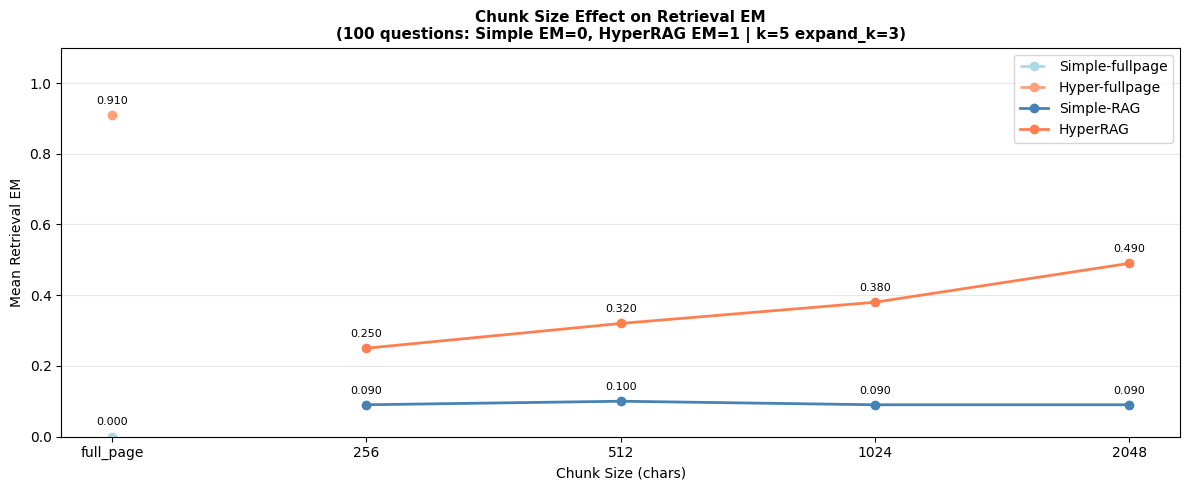

Saved: data/chunk_size_em.png


In [13]:
sys_clr = {'Simple-RAG': 'steelblue', 'HyperRAG': 'coral',
           'Simple-fullpage': 'lightblue', 'Hyper-fullpage': 'lightsalmon'}
by_sys = defaultdict(list)
for r in exp_results: by_sys[r['system']].append((str(r['chunk_size']), r['mean_em']))

xlbls = ['full_page'] + [str(cs) for cs in CHUNK_SIZES]
xmap  = {l: i for i, l in enumerate(xlbls)}

fig, ax = plt.subplots(figsize=(12, 5))
for sn, data in by_sys.items():
    xs = [xmap[cs] for cs, em in data if cs in xmap]
    ys = [em       for cs, em in data if cs in xmap]
    ax.plot(xs, ys, marker='o', label=sn, color=sys_clr.get(sn, 'gray'),
            linestyle='--' if 'fullpage' in sn else '-', linewidth=2)
    for x, y in zip(xs, ys): ax.annotate(f'{y:.3f}', (x,y), textcoords='offset points', xytext=(0,8), ha='center', fontsize=8)

ax.set_xticks(range(len(xlbls))); ax.set_xticklabels(xlbls)
ax.set_xlabel('Chunk Size (chars)'); ax.set_ylabel('Mean Retrieval EM'); ax.set_ylim(0, 1.1)
ax.set_title(
    f'Chunk Size Effect on Retrieval EM\n'
    f'({len(subset_questions)} questions: Simple EM=0, HyperRAG EM=1 | k={K} expand_k={EXPAND_K})',
    fontsize=11, fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(str(DATA_DIR / 'chunk_size_em.png'), dpi=120, bbox_inches='tight')
plt.show(); print('Saved: data/chunk_size_em.png')


---
## Section 7 -- k Value Experiment

How many chunks to retrieve?


In [14]:
K_VALS = [1, 2, 3, 5, 7, 10, 15]
KCS    = 512

print(f'Building chunk index (chunk_size={KCS})...')
ki, kd = build_chunk_index(test_corpus, KCS, CHUNK_OVERLAP)
print(f'{len(kd)} chunks')

k_results = []
for kv in K_VALS:
    for sn, fn in [
        ('Simple-RAG', lambda q, k: simple_rag_chunked(q, ki, kd, k=k)),
        ('HyperRAG',   lambda q, k: hyper_rag_chunked(q, ki, kd, corpus, graph, k=k, expand_k=EXPAND_K)),
    ]:
        ems, cls = [], []
        for q in subset_questions:
            ctx, _, _ = fn(q['question'], kv)
            ems.append(compute_em(ctx, q['answer'])); cls.append(len(ctx))
        k_results.append({'k': kv, 'system': sn,
                          'mean_em': float(np.mean(ems)), 'mean_ctx': float(np.mean(cls))})

print(f'{"k":<5} {"System":<15} {"EM":>7} {"Ctx len":>10}')
print('-'*42)
for r in k_results:
    print(f'{r["k"]:<5} {r["system"]:<15} {r["mean_em"]:>7.3f} {r["mean_ctx"]:>10,.0f}')


Building chunk index (chunk_size=512)...


Batches:   0%|          | 0/767 [00:00<?, ?it/s]

24515 chunks


Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

...

Batches:   0%|          | 0/9 [00:00<?, ?it/s]

Batches:   0%|          | 0/33 [00:00<?, ?it/s]

Batches:   0%|          | 0/109 [00:00<?, ?it/s]

Batches:   0%|          | 0/7 [00:00<?, ?it/s]

k     System               EM    Ctx len
------------------------------------------
1     Simple-RAG        0.020        449
1     HyperRAG          0.300      1,818
2     Simple-RAG        0.060        916
2     HyperRAG          0.340      2,255
3     Simple-RAG        0.090      1,395
3     HyperRAG          0.330      2,686
5     Simple-RAG        0.100      2,330
5     HyperRAG          0.320      3,668
7     Simple-RAG        0.120      3,269
7     HyperRAG          0.320      4,596
10    Simple-RAG        0.170      4,715
10    HyperRAG          0.330      6,051
15    Simple-RAG        0.230      7,140
15    HyperRAG          0.330      8,489


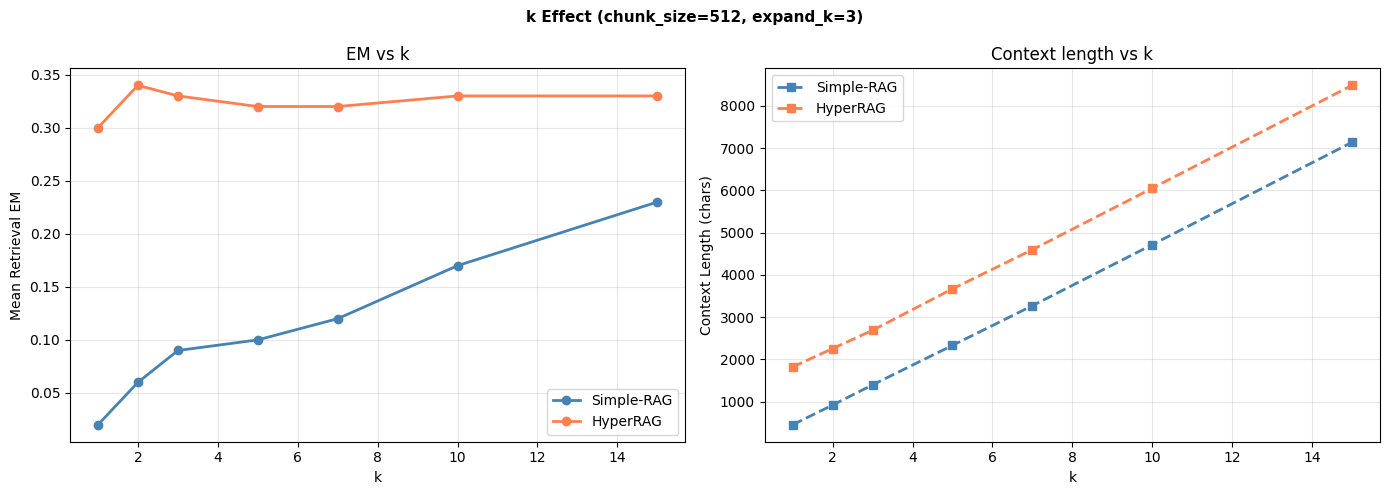

Saved: data/k_vs_em.png


In [15]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'k Effect (chunk_size={KCS}, expand_k={EXPAND_K})', fontsize=11, fontweight='bold')
bsk  = defaultdict(list)
for r in k_results: bsk[r['system']].append(r)
kclr = {'Simple-RAG': 'steelblue', 'HyperRAG': 'coral'}
for sn, data in bsk.items():
    ks = [d['k'] for d in data]; em = [d['mean_em'] for d in data]; cl = [d['mean_ctx'] for d in data]
    a1.plot(ks, em, marker='o', label=sn, color=kclr.get(sn, 'gray'), linewidth=2)
    a2.plot(ks, cl, marker='s', label=sn, color=kclr.get(sn, 'gray'), linewidth=2, linestyle='--')
a1.set_xlabel('k'); a1.set_ylabel('Mean Retrieval EM'); a1.set_title('EM vs k')
a1.legend(); a1.grid(alpha=0.3)
a2.set_xlabel('k'); a2.set_ylabel('Context Length (chars)'); a2.set_title('Context length vs k')
a2.legend(); a2.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(str(DATA_DIR / 'k_vs_em.png'), dpi=120, bbox_inches='tight')
plt.show(); print('Saved: data/k_vs_em.png')


---
## Section 8 -- Per-Question Deep Dive

For each subset question: which chunks Simple RAG and HyperRAG pick, whether answer is present.

`G`=gold supporting page  `*`=chunk contains gold answer


In [16]:
DIVE_CS = 512
DIVE_N  = 10

print(f'Building chunk index (chunk_size={DIVE_CS})...')
di, dd = build_chunk_index(test_corpus, DIVE_CS, CHUNK_OVERLAP)
print(f'{len(dd)} chunks\n')
print('='*100)

for qi, q in enumerate(subset_questions[:DIVE_N]):
    gq = set(q['supporting_titles'])
    sc, _, sc_  = simple_rag_chunked(q['question'], di, dd, k=K)
    hc, _, hc_  = hyper_rag_chunked(q['question'],  di, dd, corpus, graph, k=K, expand_k=EXPAND_K)
    sem = compute_em(sc, q['answer']); hem = compute_em(hc, q['answer'])
    print(f'Q{qi}: {q["question"][:70]}')
    print(f'  Gold: "{q["answer"]}"   Supporting: {q["supporting_titles"]}')
    print(f'  Simple EM={sem:.0f}   HyperRAG EM={hem:.0f}')
    print(f'  Simple-RAG ({len(sc_)} chunks):')
    for c in sc_:
        g = 'G' if c['title'] in gq else ' '
        a = '*' if q['answer'].lower() in c['text'].lower() else ' '
        print(f'    [{g}][{a}] sc={c["_score"]:.3f}  {c["title"][:35]}  ch{c["chunk_idx"]}/{c["n_chunks"]-1}')
    exp = hc_[K:]
    if exp:
        print(f'  HyperRAG expanded (+{len(exp)}):')
        for c in exp:
            g = 'G' if c['title'] in gq else ' '
            a = '*' if q['answer'].lower() in c['text'].lower() else ' '
            print(f'    [{g}][{a}] sc={c.get("_score",0):.3f}  {c["title"][:35]}  ch{c["chunk_idx"]}/{c["n_chunks"]-1}')
    print('-'*100)


Building chunk index (chunk_size=512)...


Batches:   0%|          | 0/767 [00:00<?, ?it/s]

24515 chunks



Batches:   0%|          | 0/13 [00:00<?, ?it/s]

Q0: Fast Cars, Danger, Fire and Knives includes guest appearances from whi
  Gold: "Jaime Meline"   Supporting: ['Fast Cars, Danger, Fire and Knives', 'El-P']
  Simple EM=0   HyperRAG EM=0
  Simple-RAG (5 chunks):
    [G][ ] sc=0.594  Fast Cars, Danger, Fire and Knives  ch0/7
    [G][ ] sc=0.565  Fast Cars, Danger, Fire and Knives  ch6/7
    [G][ ] sc=0.521  El-P  ch20/35
    [ ][ ] sc=0.505  Dr. Dre  ch15/249
    [G][ ] sc=0.497  Fast Cars, Danger, Fire and Knives  ch3/7
  HyperRAG expanded (+3):
    [ ][ ] sc=0.482  Proof (rapper)  ch21/34
    [ ][ ] sc=0.473  High Contrast  ch10/22
    [ ][ ] sc=0.460  Proof (rapper)  ch22/34
----------------------------------------------------------------------------------------------------


...

Q4: What is the birth date of the coach of the 2014-15 Michigan Wolverines
  Gold: "February 5, 1953"   Supporting: ["2014–15 Michigan Wolverines men's basketball team", 'John Beilein']
  Simple EM=0   HyperRAG EM=0
  Simple-RAG (5 chunks):
    [ ][ ] sc=0.690  2010–11 Michigan Wolverines men's b  ch33/61
    [G][ ] sc=0.671  2014–15 Michigan Wolverines men's b  ch44/95
    [G][ ] sc=0.670  2014–15 Michigan Wolverines men's b  ch45/95
    [ ][ ] sc=0.649  2010–11 Michigan Wolverines men's b  ch32/61
    [G][ ] sc=0.647  2014–15 Michigan Wolverines men's b  ch6/95
  HyperRAG expanded (+3):
    [G][ ] sc=0.606  John Beilein  ch175/186
    [G][ ] sc=0.591  John Beilein  ch136/186
    [G][ ] sc=0.577  John Beilein  ch183/186
----------------------------------------------------------------------------------------------------


Batches:   0%|          | 0/3 [00:00<?, ?it/s]

Q5: Which organization presents the award in which Chris Noonan was nomina
  Gold: "Academy of Motion Picture Arts and Sciences"   Supporting: ['Academy Award for Best Director', 'Chris Noonan']
  Simple EM=0   HyperRAG EM=1
  Simple-RAG (5 chunks):
    [G][ ] sc=0.671  Chris Noonan  ch0/8
    [G][ ] sc=0.585  Chris Noonan  ch7/8
    [G][ ] sc=0.555  Chris Noonan  ch6/8
    [G][ ] sc=0.516  Chris Noonan  ch8/8
    [G][ ] sc=0.460  Chris Noonan  ch1/8
  HyperRAG expanded (+3):
    [G][ ] sc=0.372  Academy Award for Best Director  ch21/78
    [G][ ] sc=0.343  Academy Award for Best Director  ch4/78
    [G][*] sc=0.339  Academy Award for Best Director  ch0/78
----------------------------------------------------------------------------------------------------
Q6: What book contains a poem which, along with "Beowulf" and the "Anglo-S
  Gold: "Exeter Book"   Supporting: ['Widsith', 'Kings of the Angles']
  Simple EM=1   HyperRAG EM=1
  Simple-RAG (5 chunks):
    [G][ ] sc=0.674  Kings of the

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

Q9: What type of species is a Boreo-arctic Montane species found in the mo
  Gold: "beetle"   Supporting: ['Arctic Circle', 'Carabus glabratus']
  Simple EM=0   HyperRAG EM=0
  Simple-RAG (5 chunks):
    [G][ ] sc=0.600  Arctic Circle  ch6/22
    [G][ ] sc=0.590  Arctic Circle  ch0/22
    [ ][ ] sc=0.572  Arctic fox  ch65/80
    [ ][ ] sc=0.544  Arctic fox  ch72/80
    [ ][ ] sc=0.543  Arctic fox  ch35/80
  HyperRAG expanded (+3):
    [ ][ ] sc=0.525  Arctic Ocean  ch76/122
    [ ][ ] sc=0.511  Arctic Ocean  ch57/122
    [ ][ ] sc=0.492  Arctic Ocean  ch111/122
----------------------------------------------------------------------------------------------------


---
## Section 9 -- LLM Generation Experiment (Optional)

Set `RUN_LLM = True` in config cell.


In [18]:
RUN_LLM     = True

In [19]:
if not RUN_LLM:
    print('RUN_LLM=False. Set True in config cell and rerun to enable LLM comparison.')
else:
    from transformers import pipeline as hfp
    import gc, torch

    def make_llm(mid, ic):
        task = 'text-generation' if ic else 'text2text-generation'
        print(f'Loading {mid}...')
        lm = hfp(task, model=mid, device=0 if torch.cuda.is_available() else -1, max_new_tokens=32)
        print('Loaded.'); return lm, ic

    def gen_answer(lm, ic, question, context):
        ctx = context[:MAX_CTX_CHARS]
        if ic:
            p = f'<|system|>Answer briefly.</s><|user|>Context: {ctx}\nQ: {question}</s><|assistant|>'
            return lm(p, max_new_tokens=32, do_sample=False)[0]['generated_text'].split('<|assistant|>')[-1].strip()
        p = f'Answer briefly.\nContext: {ctx}\nQuestion: {question}\nAnswer:'
        return lm(p, max_new_tokens=32, do_sample=False)[0]['generated_text'].strip()

    print('LLM utils defined.')


LLM utils defined.


In [20]:
llm_results = []
if not RUN_LLM:
    print('Skipped.')
else:
    for mlbl, mid, ic in LLM_MODELS:
        lm, ic2 = make_llm(mid, ic)
        for ecs in [512, 0]:  # 0 = full-page
            if ecs > 0:
                eidx, eds = build_chunk_index(test_corpus, ecs, CHUNK_OVERLAP); csl = str(ecs)
            else:
                eds  = [{'title':p['title'],'chunk_idx':0,'n_chunks':1,'text':p['text'],'_page_idx':i}
                        for i,p in enumerate(test_corpus)]
                ev   = embed_texts([d['text'] for d in eds])
                eidx = faiss.IndexFlatIP(ev.shape[1]); eidx.add(ev); csl = 'full_page'
            for sn, fn in [
                ('Simple-RAG', lambda q: simple_rag_chunked(q, eidx, eds, k=K)),
                ('HyperRAG',   lambda q: hyper_rag_chunked(q, eidx, eds, corpus, graph, k=K, expand_k=EXPAND_K)),
            ]:
                ems, f1s = [], []
                for q in tqdm(subset_questions, desc=f'{mlbl} cs={csl} {sn}'):
                    ctx, _, _ = fn(q['question'])
                    ans = gen_answer(lm, ic2, q['question'], ctx)
                    ems.append(compute_em(ans, q['answer'])); f1s.append(compute_f1(ans, q['answer']))
                llm_results.append({'model': mlbl, 'chunk_size': csl, 'system': sn,
                                    'mean_em': float(np.mean(ems)), 'mean_f1': float(np.mean(f1s))})
                print(f'  {mlbl} cs={csl} {sn}: EM={np.mean(ems):.3f} F1={np.mean(f1s):.3f}')
        del lm; gc.collect()
        if torch.cuda.is_available(): torch.cuda.empty_cache()
    print('\nLLM results:')
    print(f'{"Model":<18} {"Chunk":<12} {"System":<15} {"Gen EM":>8} {"Gen F1":>8}')
    print('-'*68)
    for r in llm_results:
        print(f'{r["model"]:<18} {str(r["chunk_size"]):<12} {r["system"]:<15} {r["mean_em"]:>8.3f} {r["mean_f1"]:>8.3f}')


Loading google/flan-t5-small...


config.json: 0.00B [00:00, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/308M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

...

Batches:   0%|          | 0/19 [00:00<?, ?it/s]

flan-t5-base cs=full_page Simple-RAG:   0%|          | 0/100 [00:00<?, ?it/s]

  flan-t5-base cs=full_page Simple-RAG: EM=0.010 F1=0.060


flan-t5-base cs=full_page HyperRAG:   0%|          | 0/100 [00:00<?, ?it/s]

  flan-t5-base cs=full_page HyperRAG: EM=0.010 F1=0.060

LLM results:
Model              Chunk        System            Gen EM   Gen F1
--------------------------------------------------------------------
flan-t5-small      512          Simple-RAG         0.030    0.089
flan-t5-small      512          HyperRAG           0.050    0.098
flan-t5-small      full_page    Simple-RAG         0.000    0.038
flan-t5-small      full_page    HyperRAG           0.000    0.038
flan-t5-base       512          Simple-RAG         0.030    0.084
flan-t5-base       512          HyperRAG           0.040    0.094
flan-t5-base       full_page    Simple-RAG         0.010    0.060
flan-t5-base       full_page    HyperRAG           0.010    0.060


---
## Section 10 -- Save Results and Summary


In [ ]:
out = {
    'config': {'N_QUESTIONS': N_QUESTIONS, 'CHUNK_SIZES': CHUNK_SIZES,
               'CHUNK_OVERLAP': CHUNK_OVERLAP, 'K': K, 'EXPAND_K': EXPAND_K},
    'subset_size': len(subset_questions),
    'chunk_size_results': [{k2: v for k2, v in r.items() if k2 != 'per_q_em'} for r in exp_results],
    'k_value_results': k_results,
    'llm_results': llm_results if RUN_LLM else [],
}
with open(DATA_DIR / 'results_chunk_experiment.json', 'w') as f: json.dump(out, f, indent=2)
print('Saved: data/results_chunk_experiment.json')
print()
print('FINAL SUMMARY')
print('='*55)
print(f'Subset: {len(subset_questions)} questions (Simple EM=0, HyperRAG EM=1)')
print()
for r in exp_results:
    print(f'  chunk={str(r["chunk_size"]):<12} {r["system"]:<22}: EM={r["mean_em"]:.3f}')
chunked = [r for r in exp_results if r['chunk_size'] != 'full_page']
if chunked:
    best = max(chunked, key=lambda r: r['mean_em'])
    print(f'\nBest: chunk_size={best["chunk_size"]}, system={best["system"]}, EM={best["mean_em"]:.3f}')


---
## Summary

| Experiment | Variable | Metric |
|------------|----------|--------|
| Chunk size | 256-2048 chars | Retrieval EM |
| k | 1-15 chunks | EM + context length |
| LLM model (optional) | flan-t5 variants | Generation EM |

## Root causes of identical Simple/HyperRAG scores

1. **Full-page embeddings are noisy** -- a 10K-char article averaged into one 384-dim vector
   dilutes the specific paragraph that contains the answer.

2. **LLM context too long** -- 80K chars truncated to 2000; the answer may be cut off.

3. **Both systems already retrieve the answer page** -- when Simple RAG retrieves the correct
   page, HyperRAG expanding neighbors adds no EM difference.

## How chunking helps

- More precise embeddings for each paragraph
- Shorter, focused context for the LLM to read
- HyperRAG can expand to the *specific chunk* with bridge evidence

## Next steps

| Lever | Expected effect |
|-------|----------------|
| Chunk size 128 | Even more precise, may split mid-sentence |
| Cross-encoder reranker | Rerank top chunks with stronger model |
| BM25 hybrid retrieval | Combine keyword + semantic |
| Larger LLM | Better extraction from noisy context |
| Larger corpus | More graph edges, richer expansion |
